In [3]:
import CLAUDE as claude

In [4]:
import numpy as np
import pandas as pd

In [5]:
da = claude.CLAUDE(nDescriptor = 1, \
                   nTarget = 2, \
                   degreePolynomialDescriptor = np.array([[0],[1],[2],[3]]), \
                   degreeActiveDescriptor = [[[0],[0,1]]])

df = pd.read_csv('exampledata.csv', skipinitialspace=True)
xSample = df[['descriptor']].values
ySample = df[['target1','target2']].values

da.fit(xSample,ySample)

x = np.arange(0.0,1.0+1e-6,0.01)
y = da.predict(x)

x = x.reshape(-1, 1)

aq = da.acquisitionFunction(x)
idxMax1 = np.argmax(aq[:,0])
idxMax2 = np.argmax(aq[:,1])

da.saveModelParameterToFile()
da.saveCovarianceMatrixToFile()

In [6]:
import matplotlib.pyplot as plt

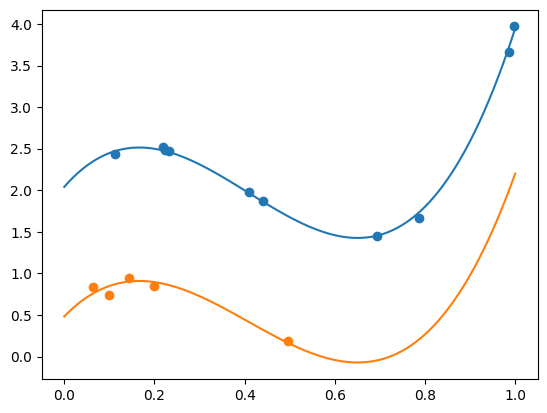

In [7]:
plt.plot(x, y[:,0], label='target1')
plt.plot(x, y[:,1], label='target2')
plt.scatter(xSample, ySample[:,0])
plt.scatter(xSample, ySample[:,1])

In [8]:
from scipy.optimize import curve_fit

In [9]:
def third_degree(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

In [10]:
def_expt = df.dropna(subset=['target1'])
def_comp = df.dropna(subset=['target2'])

x_expt = def_expt['descriptor'].values
y_expt = def_expt['target1'].values

x_comp = def_comp['descriptor'].values
y_comp = def_comp['target2'].values

In [11]:
p0 = [0,0,0,0]
popt_expt, pcov_expt = curve_fit(third_degree, x_expt, y_expt, p0=p0)
popt_comp, pcov_comp = curve_fit(third_degree, x_comp, y_comp, p0=p0)

In [12]:
ols_expt = third_degree(x, *popt_expt)
ols_comp = third_degree(x, *popt_comp)

In [16]:
da_res = da.predict(x)

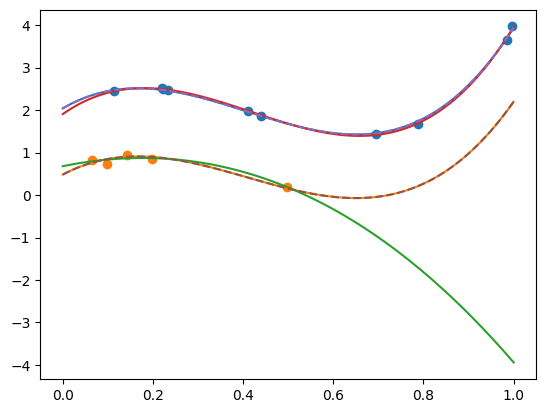

In [19]:
plt.plot(x, y[:,0], label='target1')
plt.plot(x, y[:,1], label='target2')
plt.scatter(xSample, ySample[:,0])
plt.scatter(xSample, ySample[:,1])

plt.plot(x, ols_comp, label='OLS target2')
plt.plot(x, ols_expt, label='OLS target1')

plt.plot(x, da_res[:,0], label='DA target1', linestyle='--')
plt.plot(x, da_res[:,1], label='DA target2', linestyle='--')